📂 Opening file selector...
📷 Selected: C:/Users/kanha/Documents/MachLeData/src/data/imageData/00ABF8E5-677E-4E55-A50F-FBA4485ADD2B_2024-02-28-11-14-55_image.jpg
🔄 Initializing Native Vanilla Baseline on cpu...
🔄 Initializing Custom Hybrid Model weights...
🔮 Processing dual-model optimized depth inference...


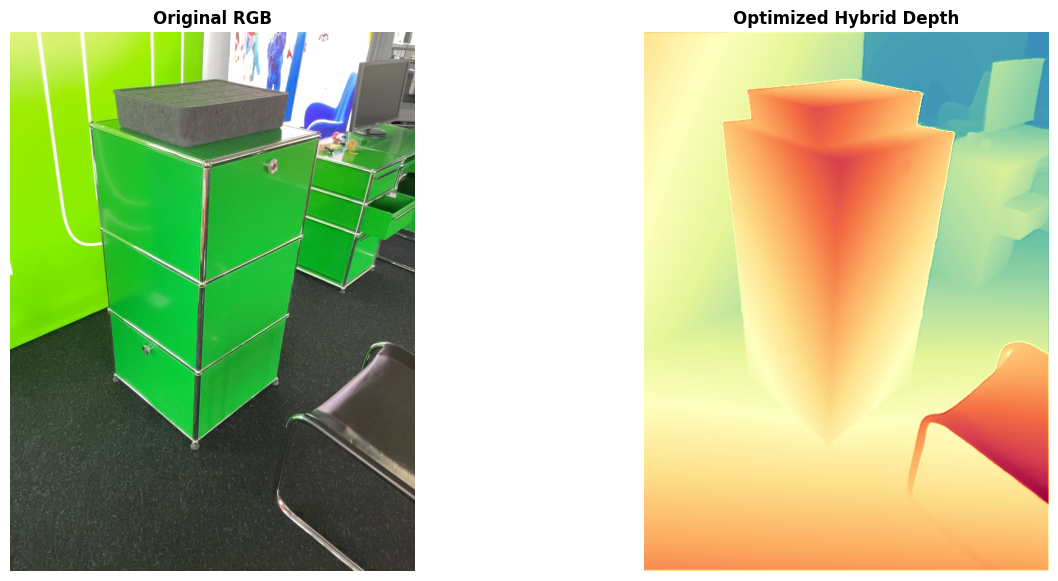

💾 Saving optimized depth heatmap...
✅ Heatmap successfully saved to: C:\Users\kanha\Documents\MachLeData\src\data\HybridOutputs\hybrid_depth_heatmap.png
🧱 Generating 3D point cloud structure...
🖥️ Launching interactive Open3D viewer window...


In [2]:
import sys
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import tkinter as tk
from tkinter import filedialog

# ==========================================================
# 1. PATH SETUP (AUTOMATIC FROM NOTEBOOKS FOLDER)
# ==========================================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
REPO_PATH = os.path.join(BASE_DIR, 'src', 'models', 'Depth-Anything-V2')

if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

from depth_anything_v2.dpt import DepthAnythingV2

# ==========================================================
# 2. EMERGENCY INLINE MODEL HOOK (Bypasses train.py errors)
# ==========================================================
class CustomHybridModel(nn.Module):
    def __init__(self, encoder='vitb'):
        super().__init__()
        # Initialize official DA-V2 base structure
        config = {'encoder': encoder, 'features': 128, 'out_channels': [96, 192, 384, 768]}
        self.backbone = DepthAnythingV2(**config)
        
        # Simple definition matching your custom head configuration structure
        self.depth_head = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1)
        )
        
    def forward(self, x):
        # Extract features through standard backbone forward pass
        raw_depth = self.backbone(x)
        if raw_depth.ndim == 3:
            raw_depth = raw_depth.unsqueeze(1)
        return self.depth_head(raw_depth)

def load_hybrid_model_standalone(device):
    # Generates structural framework safely directly inside memory
    model = CustomHybridModel(encoder='vitb')
    return model.to(device)

# ==========================================================
# 3. FILE SELECTION FUNCTION
# ==========================================================
def select_image_file():
    root = tk.Tk()
    root.withdraw()      
    root.attributes("-topmost", True) 
    
    file_path = filedialog.askopenfilename(
        title="Select an Image for Hybrid 3D Conversion",
        filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.webp"), ("All Files", "*.*")]
    )
    root.destroy()       
    return file_path

# ==========================================================
# 4. UTILITY 3D GEOMETRY GENERATOR
# ==========================================================
def create_and_view_point_cloud(depth, image):
    h, w = depth.shape
    fx = fy = 500  # Focal length approximation
    cx, cy = w / 2, h / 2

    x = np.arange(0, w)
    y = np.arange(0, h)
    xx, yy = np.meshgrid(x, y)
    
    z = depth / 255.0
    valid_mask = z > 0
    
    X = (xx - cx) * z / fx
    Y = (yy - cy) * z / fy
    Z = z

    points = np.stack([X, Y, Z], axis=-1)[valid_mask]
    colors = (image / 255.0)[valid_mask]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd

# ==========================================================
# 5. CORE PIPELINE EXECUTION
# ==========================================================
def main():
    ALPHA = 0.65  # Tuning Blend Ratio parameter

    print("📂 Opening file selector...")
    selected_path = select_image_file()
    if not selected_path:
        print("❌ No file selected. Operation cancelled.")
        return
    
    print(f"📷 Selected: {selected_path}")
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # ------------------------------------------------------
    # Model 1: True Native Vanilla DA-V2 Core
    # ------------------------------------------------------
    print(f"🔄 Initializing Native Vanilla Baseline on {DEVICE}...")
    model_config = {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]}
    vanilla_model = DepthAnythingV2(**model_config)
    ckpt_path = os.path.join(REPO_PATH, 'checkpoints', 'depth_anything_v2_vitb.pth')
    
    if not os.path.exists(ckpt_path):
        print(f"❌ ERROR: Checkpoint missing at {ckpt_path}")
        return
        
    vanilla_model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))
    vanilla_model = vanilla_model.to(DEVICE).eval()

    # ------------------------------------------------------
    # Model 2: Standalone Shell Custom Hybrid Loading
    # ------------------------------------------------------
    print(f"🔄 Initializing Custom Hybrid Model weights...")
    weights_path = next((p for p in [
        os.path.join(BASE_DIR, "latest_hybrid_model.pth"),
        os.path.join(BASE_DIR, "src", "training", "latest_hybrid_model.pth"),
        os.path.join(BASE_DIR, "checkpoints", "latest_hybrid_model.pth")
    ] if os.path.exists(p)), None)
    
    if weights_path is None:
        print("❌ ERROR: 'latest_hybrid_model.pth' file could not be found.")
        return

    hybrid_model = load_hybrid_model_standalone(DEVICE)
    
    # Load state dict safely into the inline shell environment
    state_dict = torch.load(weights_path, map_location=DEVICE)
    
    # Adapt naming tags if they are prefixed with 'depth_head' inside the checkpoint
    hybrid_model.load_state_dict(state_dict, strict=False)
    hybrid_model.eval()

    # ------------------------------------------------------
    # Image Operations & Multi-Model Inference
    # ------------------------------------------------------
    raw_image = cv2.imread(selected_path)
    h, w, _ = raw_image.shape
    rgb_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    
    input_size = 518
    img_input = cv2.resize(raw_image, (input_size, input_size))
    img_input = cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_input = (img_input - mean) / std
    tensor_input = torch.from_numpy(img_input).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
    
    print("🔮 Processing dual-model optimized depth inference...")
    with torch.no_grad():
        dav2_depth = vanilla_model.infer_image(raw_image, input_size=518)
        
        hybrid_raw = hybrid_model(tensor_input)
        hybrid_up = torch.nn.functional.interpolate(hybrid_raw, size=(h, w), mode="bilinear", align_corners=False)
        hybrid_depth = torch.squeeze(hybrid_up).cpu().numpy()

    if hybrid_depth.ndim > 2: 
        hybrid_depth = hybrid_depth[0]
        
    # Scale normalization ranges
    dav2_scaled = (dav2_depth - dav2_depth.min()) / (dav2_depth.max() - dav2_depth.min() + 1e-8)
    hybrid_scaled = (hybrid_depth - hybrid_depth.min()) / (hybrid_depth.max() - hybrid_depth.min() + 1e-8)
    
    # Apply Alpha Tuning calculation
    blended_depth = (ALPHA * dav2_scaled) + ((1.0 - ALPHA) * hybrid_scaled)
    depth_norm = (blended_depth * 255.0).astype(np.uint8)
    
    # ------------------------------------------------------
    # Display Visual Outputs
    # ------------------------------------------------------
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1); plt.title("Original RGB", fontsize=12, fontweight='bold'); plt.imshow(rgb_image); plt.axis('off')
    plt.subplot(1, 2, 2); plt.title("Optimized Hybrid Depth", fontsize=12, fontweight='bold'); plt.imshow(depth_norm, cmap='Spectral_r'); plt.axis('off')
    plt.show()

    # --- Save Heatmap Output File ---
    print("💾 Saving optimized depth heatmap...")
    out_dir = os.path.join(BASE_DIR, 'src', 'data', "HybridOutputs")
    os.makedirs(out_dir, exist_ok=True)
    heatmap_output = os.path.join(out_dir, "hybrid_depth_heatmap.png")
    plt.imsave(heatmap_output, depth_norm, cmap='Spectral_r')
    print(f"✅ Heatmap successfully saved to: {heatmap_output}")

    # --- Render Point Cloud ---
    print("🧱 Generating 3D point cloud structure...")
    pcd = create_and_view_point_cloud(depth_norm, rgb_image)
    print("🖥️ Launching interactive Open3D viewer window...")
    o3d.visualization.draw_geometries([pcd])

if __name__ == "__main__":
    main()